# Factor Risk Analysis: Understanding the Drivers of Portfolio Returns

## Research Question

**What systematic factors explain the returns and risk of a diversified multi-asset portfolio, and how stable are those exposures over time?**

## Project Objective

This project investigates the systematic drivers of returns across a diversified set of financial assets using a multi-factor framework.

Rather than focusing exclusively on total volatility, the analysis decomposes asset behavior into exposures to economically meaningful risk factors, including equity market conditions, financial uncertainty, interest rates, the U.S. dollar, and commodity dynamics.

The project places particular emphasis on the stability of factor exposures through time. Rolling regressions are used to determine whether estimated sensitivities remain stable or change across different market environments.

## Asset Universe

The analysis considers eight exchange-traded funds representing different asset classes and geographic exposures:

- **SPY** — U.S. large-cap equities
- **QQQ** — U.S. technology-oriented equities
- **IWM** — U.S. small-cap equities
- **ECH** — Chilean equities
- **TLT** — Long-term U.S. Treasury bonds
- **GLD** — Gold
- **EMB** — Emerging-market bonds
- **CPER** — Copper

## Main Research Dimensions

1. Which systematic factors explain the returns of each asset?
2. How large and statistically significant are the estimated factor exposures?
3. How much of each asset's return variation can be explained by the factor model?
4. Are factor exposures stable through time?
5. How do factor sensitivities change during periods of financial stress?
6. What do these exposures imply for portfolio diversification and risk management?

## Methodology and Factor Definition

The analysis uses a multi-factor regression framework to estimate the sensitivity of asset returns to a set of systematic financial and macroeconomic drivers.

The baseline specification is:

\[
R_{i,t} = \alpha_i
+ \beta_{MKT,i} MKT_t
+ \beta_{VIX,i} \Delta VIX_t
+ \beta_{RATE,i} \Delta YIELD_t
+ \beta_{USD,i} USD_t
+ \beta_{COM,i} COM_t
+ \varepsilon_{i,t}
\]

where:

- **\(R_{i,t}\)**: return of asset \(i\) at time \(t\).
- **MKT**: equity market factor, represented by SPY returns.
- **ΔVIX**: change in the CBOE Volatility Index, capturing changes in market uncertainty and risk aversion.
- **ΔYIELD**: change in the U.S. 10-year Treasury yield, representing interest-rate shocks.
- **USD**: return of the U.S. Dollar Index, capturing changes in broad dollar conditions.
- **COM**: copper return, used as a proxy for commodity and global cyclical conditions.
- **\(\alpha_i\)**: component of average return not explained by the included factors.
- **\(\beta_{k,i}\)**: sensitivity of asset \(i\) to systematic factor \(k\).
- **\(\varepsilon_{i,t}\)**: idiosyncratic return component.

### Empirical Strategy

The analysis is conducted in four stages:

1. **Factor construction and exploratory analysis**
   - Align asset and factor data.
   - Transform each series into economically appropriate returns or changes.
   - Examine descriptive statistics and correlations.

2. **Static factor estimation**
   - Estimate multi-factor regressions for each asset.
   - Evaluate factor coefficients, statistical significance, and explanatory power.

3. **Dynamic factor exposure**
   - Estimate rolling regressions to study time variation in factor betas.
   - Compare exposure stability across assets and factors.

4. **Risk interpretation and stress analysis**
   - Examine factor behavior during periods of elevated financial stress.
   - Assess the implications of changing factor exposures for diversification and portfolio risk management.

The objective is not to interpret the estimated relationships as causal effects, but as empirical measures of systematic financial exposure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

# Load clean asset prices
prices = pd.read_csv(
    "data/prices_clean.csv",
    index_col=0,
    parse_dates=True
)

print("Data dimensions:", prices.shape)
print("Start date:", prices.index.min())
print("End date:", prices.index.max())
print("\nAssets:")
print(prices.columns.tolist())
print("\nMissing values:")
print(prices.isna().sum())

Data dimensions: (2766, 8)
Start date: 2015-01-02 00:00:00
End date: 2025-12-31 00:00:00

Assets:
['CPER', 'ECH', 'EMB', 'GLD', 'IWM', 'QQQ', 'SPY', 'TLT']

Missing values:
CPER    0
ECH     0
EMB     0
GLD     0
IWM     0
QQQ     0
SPY     0
TLT     0
dtype: int64


In [2]:
# Compute daily simple returns
asset_returns = prices.pct_change().dropna()

print("Return dimensions:", asset_returns.shape)
print("Start date:", asset_returns.index.min())
print("End date:", asset_returns.index.max())

print("\nDescriptive statistics:")
display(
    asset_returns.describe().T[
        ["mean", "std", "min", "max"]
    ].round(4)
)

Return dimensions: (2765, 8)
Start date: 2015-01-05 00:00:00
End date: 2025-12-31 00:00:00

Descriptive statistics:


,mean,std,min,max
CPER,0.0003,0.0154,-0.1931,0.1095
ECH,0.0003,0.0166,-0.1561,0.1198
EMB,0.0002,0.0061,-0.0922,0.0460
GLD,0.0005,0.0093,-0.0643,0.0490
IWM,0.0004,0.0142,-0.1327,0.0915
QQQ,0.0008,0.0138,-0.1198,0.1200
SPY,0.0006,0.0112,-0.1094,0.1050
TLT,0.0000,0.0095,-0.0667,0.0752


In [3]:
import yfinance as yf

factor_tickers = {
    "VIX": "^VIX",
    "US10Y": "^TNX",
    "USD": "DX-Y.NYB"
}

for name, ticker in factor_tickers.items():
    data = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False
    )
    
    print(f"{name} ({ticker}): {data.shape}")
    print(
        "Dates:",
        data.index.min(),
        "to",
        data.index.max()
    )
    print()

VIX (^VIX): (2766, 6)
Dates: 2015-01-02 00:00:00 to 2025-12-31 00:00:00

US10Y (^TNX): (2765, 6)
Dates: 2015-01-02 00:00:00 to 2025-12-31 00:00:00

USD (DX-Y.NYB): (2767, 6)
Dates: 2015-01-02 00:00:00 to 2025-12-31 00:00:00



In [4]:
# Download factor levels
vix_raw = yf.download(
    "^VIX",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)["Close"].squeeze()

us10y_raw = yf.download(
    "^TNX",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)["Close"].squeeze()

usd_raw = yf.download(
    "DX-Y.NYB",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)["Close"].squeeze()

# Construct factor series
factors = pd.DataFrame(index=asset_returns.index)

factors["MKT"] = asset_returns["SPY"]
factors["VIX"] = vix_raw.diff()
factors["RATE"] = us10y_raw.diff()
factors["USD"] = usd_raw.pct_change()
factors["COM"] = asset_returns["CPER"]

# Keep only dates with complete factor information
factors = factors.dropna()

print("Factor dimensions:", factors.shape)
print("Start date:", factors.index.min())
print("End date:", factors.index.max())

print("\nMissing values:")
print(factors.isna().sum())

print("\nDescriptive statistics:")
display(factors.describe().T[["mean", "std", "min", "max"]].round(4))

Factor dimensions: (2763, 5)
Start date: 2015-01-05 00:00:00
End date: 2025-12-31 00:00:00

Missing values:
MKT     0
VIX     0
RATE    0
USD     0
COM     0
dtype: int64

Descriptive statistics:


,mean,std,min,max
MKT,0.0006,0.0112,-0.1094,0.1050
VIX,-0.0008,1.9534,-18.7100,24.8600
RATE,0.0007,0.0538,-0.3220,0.2690
USD,0.0000,0.0044,-0.0237,0.0205
COM,0.0003,0.0154,-0.1931,0.1095


In [5]:
# Align asset returns and factors on common dates
model_data = asset_returns.join(
    factors.add_prefix("F_"),
    how="inner"
).dropna()

asset_cols = asset_returns.columns.tolist()
factor_cols = ["F_MKT", "F_VIX", "F_RATE", "F_USD", "F_COM"]

print("Model data dimensions:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

print("\nAsset columns:")
print(asset_cols)

print("\nFactor columns:")
print(factor_cols)

print("\nTotal missing values:", model_data.isna().sum().sum())

Model data dimensions: (2763, 13)
Start date: 2015-01-05 00:00:00
End date: 2025-12-31 00:00:00

Asset columns:
['CPER', 'ECH', 'EMB', 'GLD', 'IWM', 'QQQ', 'SPY', 'TLT']

Factor columns:
['F_MKT', 'F_VIX', 'F_RATE', 'F_USD', 'F_COM']

Total missing values: 0


In [6]:
# Factor correlation matrix
factor_corr = model_data[factor_cols].corr()

print("Factor correlation matrix:")
display(factor_corr.round(3))

Factor correlation matrix:


,F_MKT,F_VIX,F_RATE,F_USD,F_COM
F_MKT,1.000,-0.794,0.159,-0.088,0.334
F_VIX,-0.794,1.000,-0.167,-0.003,-0.290
F_RATE,0.159,-0.167,1.000,0.282,0.069
F_USD,-0.088,-0.003,0.282,1.000,-0.266
F_COM,0.334,-0.290,0.069,-0.266,1.000


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare factor matrix for VIF analysis
X_vif = model_data[factor_cols].copy()
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

print("Variance Inflation Factors:")
display(vif_table.round(2))

Variance Inflation Factors:


,Variable,VIF
0,const,1.01
1,F_MKT,2.84
2,F_VIX,2.76
3,F_RATE,1.14
4,F_USD,1.21
5,F_COM,1.22


In [8]:
# Multi-factor regression for ECH
y = model_data["ECH"]
X = model_data[factor_cols]

X = sm.add_constant(X)

ech_model = sm.OLS(y, X).fit(cov_type="HC3")

print(ech_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ECH   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     150.3
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          1.88e-141
Time:                        22:06:48   Log-Likelihood:                 8014.7
No. Observations:                2763   AIC:                        -1.602e+04
Df Residuals:                    2757   BIC:                        -1.598e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.746e-05      0.000     -0.260      0.7

In [9]:
# Estimate multi-factor models for all assets
regression_results = []

for asset in asset_cols:
    y = model_data[asset]
    X = sm.add_constant(model_data[factor_cols])

    model = sm.OLS(y, X).fit(cov_type="HC3")

    regression_results.append({
        "Asset": asset,
        "Alpha": model.params["const"],
        "MKT": model.params["F_MKT"],
        "VIX": model.params["F_VIX"],
        "RATE": model.params["F_RATE"],
        "USD": model.params["F_USD"],
        "COM": model.params["F_COM"],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj
    })

factor_exposures = pd.DataFrame(regression_results).set_index("Asset")

print("Multi-factor exposure estimates:")
display(factor_exposures.round(4))

Multi-factor exposure estimates:


,Alpha,MKT,VIX,RATE,USD,COM,R2,Adj_R2
Asset,,,,,,,,
CPER,0.0000,0.0000,0.0000,-0.0000,-0.0000,1.0000,1.0000,1.0000
ECH,-0.0001,0.5351,-0.0010,-0.0005,-0.6459,0.1828,0.3536,0.3524
EMB,0.0000,0.2910,-0.0003,-0.0494,-0.1442,0.0137,0.5515,0.5507
GLD,0.0005,-0.0224,-0.0001,-0.0440,-0.6765,0.1086,0.2693,0.2680
IWM,-0.0002,1.0554,-0.0002,0.0009,-0.0863,0.0250,0.7550,0.7545
QQQ,0.0001,1.1692,-0.0000,-0.0119,0.0738,-0.0138,0.8744,0.8741
SPY,-0.0000,1.0000,-0.0000,0.0000,-0.0000,0.0000,1.0000,1.0000
TLT,0.0002,-0.0429,-0.0001,-0.1594,0.1435,-0.0005,0.8010,0.8006


In [10]:
# Assets used as dependent variables in the factor analysis
analysis_assets = ["ECH", "EMB", "GLD", "IWM", "QQQ", "TLT"]

detailed_results = []

for asset in analysis_assets:
    y = model_data[asset]
    X = sm.add_constant(model_data[factor_cols])

    model = sm.OLS(y, X).fit(cov_type="HC3")

    for factor in factor_cols:
        detailed_results.append({
            "Asset": asset,
            "Factor": factor.replace("F_", ""),
            "Beta": model.params[factor],
            "P_value": model.pvalues[factor]
        })

factor_significance = pd.DataFrame(detailed_results)

factor_significance["Significant_5pct"] = (
    factor_significance["P_value"] < 0.05
)

display(
    factor_significance.round({
        "Beta": 4,
        "P_value": 4
    })
)

,Asset,Factor,Beta,P_value,Significant_5pct
0,ECH,MKT,0.5351,0.0000,True
1,ECH,VIX,-0.0010,0.0028,True
2,ECH,RATE,-0.0005,0.9479,False
3,ECH,USD,-0.6459,0.0000,True
4,ECH,COM,0.1828,0.0000,True
5,EMB,MKT,0.2910,0.0000,True
6,EMB,VIX,-0.0003,0.0869,False
7,EMB,RATE,-0.0494,0.0000,True
8,EMB,USD,-0.1442,0.0000,True
9,EMB,COM,0.0137,0.1032,False


In [11]:
# Model explanatory power by asset
model_fit_results = []

for asset in analysis_assets:
    y = model_data[asset]
    X = sm.add_constant(model_data[factor_cols])

    model = sm.OLS(y, X).fit(cov_type="HC3")

    model_fit_results.append({
        "Asset": asset,
        "R2": model.rsquared,
        "Adjusted_R2": model.rsquared_adj
    })

model_fit = (
    pd.DataFrame(model_fit_results)
    .set_index("Asset")
    .sort_values("R2", ascending=False)
)

model_fit["R2_pct"] = model_fit["R2"] * 100
model_fit["Adjusted_R2_pct"] = model_fit["Adjusted_R2"] * 100

print("Model explanatory power:")
display(
    model_fit[
        ["R2_pct", "Adjusted_R2_pct"]
    ].round(2)
)

Model explanatory power:


,R2_pct,Adjusted_R2_pct
Asset,,
QQQ,87.44,87.41
TLT,80.10,80.06
IWM,75.50,75.45
EMB,55.15,55.07
ECH,35.36,35.24
GLD,26.93,26.80


In [12]:
# Rolling multi-factor regression function

def rolling_factor_betas(data, asset, factors, window=252):
    """
    Estimate rolling OLS factor exposures using a fixed-length window.
    
    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing asset returns and factor series.
    asset : str
        Asset used as dependent variable.
    factors : list
        Factor column names.
    window : int
        Rolling estimation window in trading days.
    
    Returns
    -------
    pandas.DataFrame
        Time series of rolling alpha, factor betas and R-squared.
    """
    
    results = []

    for end in range(window, len(data) + 1):
        sample = data.iloc[end - window:end]

        y = sample[asset]
        X = sm.add_constant(sample[factors])

        model = sm.OLS(y, X).fit()

        row = {
            "Date": sample.index[-1],
            "Alpha": model.params["const"],
            "R2": model.rsquared
        }

        for factor in factors:
            row[factor] = model.params[factor]

        results.append(row)

    return pd.DataFrame(results).set_index("Date")

In [13]:
# Estimate 252-day rolling factor exposures for ECH

ech_rolling = rolling_factor_betas(
    data=model_data,
    asset="ECH",
    factors=factor_cols,
    window=252
)

print("ECH rolling regression dimensions:", ech_rolling.shape)
print("Start date:", ech_rolling.index.min())
print("End date:", ech_rolling.index.max())

print("\nSummary of rolling factor exposures:")
display(
    ech_rolling[
        ["F_MKT", "F_VIX", "F_RATE", "F_USD", "F_COM", "R2"]
    ].describe().T[
        ["mean", "std", "min", "max"]
    ].round(4)
)

ECH rolling regression dimensions: (2512, 7)
Start date: 2016-01-04 00:00:00
End date: 2025-12-31 00:00:00

Summary of rolling factor exposures:


,mean,std,min,max
F_MKT,0.5051,0.2014,0.1209,1.2194
F_VIX,-0.0011,0.0009,-0.0045,0.0021
F_RATE,0.0018,0.0245,-0.0416,0.0937
F_USD,-0.6493,0.1643,-1.5395,-0.2704
F_COM,0.2233,0.1027,0.0108,0.5153
R2,0.3739,0.1152,0.0981,0.6039


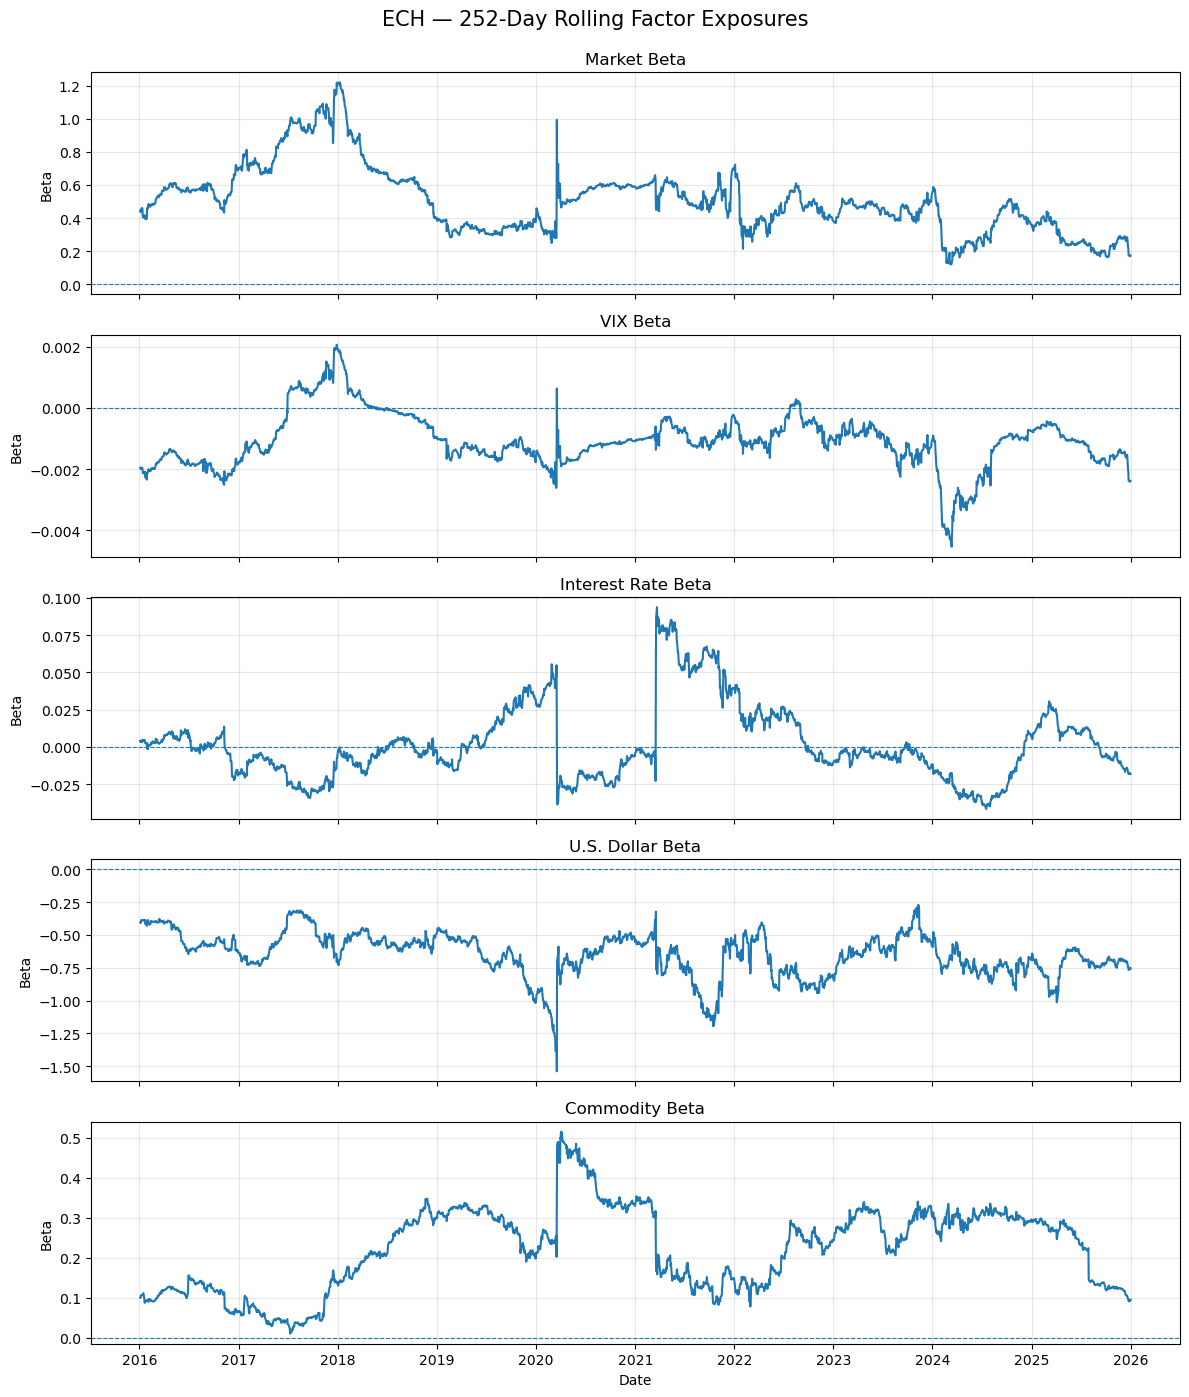

In [14]:
# Plot rolling factor exposures for ECH

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 14),
    sharex=True
)

factors_to_plot = [
    ("F_MKT", "Market Beta"),
    ("F_VIX", "VIX Beta"),
    ("F_RATE", "Interest Rate Beta"),
    ("F_USD", "U.S. Dollar Beta"),
    ("F_COM", "Commodity Beta")
]

for ax, (factor, title) in zip(axes, factors_to_plot):
    ax.plot(
        ech_rolling.index,
        ech_rolling[factor],
        linewidth=1.5
    )

    ax.axhline(
        0,
        linewidth=0.8,
        linestyle="--"
    )

    ax.set_title(title)
    ax.set_ylabel("Beta")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "ECH — 252-Day Rolling Factor Exposures",
    fontsize=15,
    y=0.995
)

plt.tight_layout()

plt.savefig(
    "figures/ech_rolling_factor_exposures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Estimate rolling factor exposures for all analysis assets

rolling_results = {}

for asset in analysis_assets:
    rolling_results[asset] = rolling_factor_betas(
        data=model_data,
        asset=asset,
        factors=factor_cols,
        window=252
    )

print("Rolling regressions completed.")

for asset, result in rolling_results.items():
    print(
        f"{asset}: {result.shape[0]} windows | "
        f"{result.index.min().date()} to {result.index.max().date()}"
    )

Rolling regressions completed.
ECH: 2512 windows | 2016-01-04 to 2025-12-31
EMB: 2512 windows | 2016-01-04 to 2025-12-31
GLD: 2512 windows | 2016-01-04 to 2025-12-31
IWM: 2512 windows | 2016-01-04 to 2025-12-31
QQQ: 2512 windows | 2016-01-04 to 2025-12-31
TLT: 2512 windows | 2016-01-04 to 2025-12-31


In [17]:
# Measure rolling factor exposure stability

stability_results = []

for asset in analysis_assets:
    rolling_df = rolling_results[asset]

    for factor in factor_cols:
        beta_series = rolling_df[factor]

        stability_results.append({
            "Asset": asset,
            "Factor": factor.replace("F_", ""),
            "Mean_Beta": beta_series.mean(),
            "Beta_STD": beta_series.std(),
            "Min_Beta": beta_series.min(),
            "Max_Beta": beta_series.max(),
            "Beta_Range": beta_series.max() - beta_series.min()
        })

beta_stability = pd.DataFrame(stability_results)

print("Rolling beta stability:")
display(
    beta_stability.round(4)
)

Rolling beta stability:


,Asset,Factor,Mean_Beta,Beta_STD,Min_Beta,Max_Beta,Beta_Range
0,ECH,MKT,0.5051,0.2014,0.1209,1.2194,1.0985
1,ECH,VIX,-0.0011,0.0009,-0.0045,0.0021,0.0066
2,ECH,RATE,0.0018,0.0245,-0.0416,0.0937,0.1353
3,ECH,USD,-0.6493,0.1643,-1.5395,-0.2704,1.2691
4,ECH,COM,0.2233,0.1027,0.0108,0.5153,0.5045
5,EMB,MKT,0.2250,0.0851,0.0176,0.6678,0.6502
6,EMB,VIX,-0.0005,0.0003,-0.0012,0.0009,0.0022
7,EMB,RATE,-0.0481,0.0149,-0.0895,-0.0078,0.0818
8,EMB,USD,-0.1438,0.0820,-0.3752,0.1163,0.4914
9,EMB,COM,0.0192,0.0455,-0.0474,0.1901,0.2375


In [18]:
# Measure sign persistence of rolling factor exposures

sign_persistence_results = []

for asset in analysis_assets:
    rolling_df = rolling_results[asset]

    for factor in factor_cols:
        beta_series = rolling_df[factor]
        mean_beta = beta_series.mean()

        if mean_beta > 0:
            same_sign = (beta_series > 0).mean()
        elif mean_beta < 0:
            same_sign = (beta_series < 0).mean()
        else:
            same_sign = np.nan

        sign_persistence_results.append({
            "Asset": asset,
            "Factor": factor.replace("F_", ""),
            "Mean_Beta": mean_beta,
            "Sign_Persistence_pct": same_sign * 100
        })

sign_persistence = pd.DataFrame(sign_persistence_results)

print("Rolling beta sign persistence:")
display(
    sign_persistence.round({
        "Mean_Beta": 4,
        "Sign_Persistence_pct": 2
    })
)

Rolling beta sign persistence:


,Asset,Factor,Mean_Beta,Sign_Persistence_pct
0,ECH,MKT,0.5051,100.00
1,ECH,VIX,-0.0011,89.97
2,ECH,RATE,0.0018,42.52
3,ECH,USD,-0.6493,100.00
4,ECH,COM,0.2233,100.00
5,EMB,MKT,0.2250,100.00
6,EMB,VIX,-0.0005,98.33
7,EMB,RATE,-0.0481,100.00
8,EMB,USD,-0.1438,96.14
9,EMB,COM,0.0192,69.27


In [19]:
# Rolling explanatory power across assets

rolling_r2_results = []

for asset in analysis_assets:
    r2_series = rolling_results[asset]["R2"]

    rolling_r2_results.append({
        "Asset": asset,
        "Mean_R2_pct": r2_series.mean() * 100,
        "STD_R2_pct": r2_series.std() * 100,
        "Min_R2_pct": r2_series.min() * 100,
        "Max_R2_pct": r2_series.max() * 100
    })

rolling_r2_summary = (
    pd.DataFrame(rolling_r2_results)
    .set_index("Asset")
    .sort_values("Mean_R2_pct", ascending=False)
)

print("Rolling model explanatory power:")
display(rolling_r2_summary.round(2))

Rolling model explanatory power:


,Mean_R2_pct,STD_R2_pct,Min_R2_pct,Max_R2_pct
Asset,,,,
QQQ,86.78,6.47,65.81,95.44
TLT,82.61,3.20,76.58,89.90
IWM,74.77,9.29,55.36,90.17
EMB,57.09,15.94,26.92,85.07
GLD,38.67,10.94,19.48,58.04
ECH,37.39,11.52,9.81,60.39


In [20]:
# Define selected financial stress periods

stress_periods = {
    "COVID-19 Shock": (
        "2020-02-19",
        "2020-04-30"
    ),
    "2022 Tightening Shock": (
        "2022-01-03",
        "2022-10-31"
    ),
    "2025 Market Uncertainty Shock": (
        "2025-02-01",
        "2025-05-31"
    )
}

print("Selected stress periods:")

for name, (start, end) in stress_periods.items():
    print(f"{name}: {start} to {end}")

Selected stress periods:
COVID-19 Shock: 2020-02-19 to 2020-04-30
2022 Tightening Shock: 2022-01-03 to 2022-10-31
2025 Market Uncertainty Shock: 2025-02-01 to 2025-05-31


In [21]:
# Asset performance during selected stress periods

stress_asset_results = []

for period_name, (start, end) in stress_periods.items():
    
    period_returns = asset_returns.loc[start:end, analysis_assets]

    cumulative_returns = (
        (1 + period_returns).prod() - 1
    ) * 100

    annualized_volatility = (
        period_returns.std() * np.sqrt(252)
    ) * 100

    for asset in analysis_assets:
        stress_asset_results.append({
            "Period": period_name,
            "Asset": asset,
            "Cumulative_Return_pct": cumulative_returns[asset],
            "Annualized_Volatility_pct": annualized_volatility[asset]
        })

stress_asset_performance = pd.DataFrame(stress_asset_results)

print("Asset performance during stress periods:")

display(
    stress_asset_performance.round(2)
)

Asset performance during stress periods:


,Period,Asset,Cumulative_Return_pct,Annualized_Volatility_pct
0,COVID-19 Shock,ECH,-17.42,72.83
1,COVID-19 Shock,EMB,-13.01,39.99
2,COVID-19 Shock,GLD,5.23,29.43
3,COVID-19 Shock,IWM,-21.92,73.73
4,COVID-19 Shock,QQQ,-6.54,65.86
5,COVID-19 Shock,TLT,14.90,40.93
6,2022 Tightening Shock,ECH,11.04,35.53
7,2022 Tightening Shock,EMB,-25.06,14.93
8,2022 Tightening Shock,GLD,-11.14,14.75
9,2022 Tightening Shock,IWM,-16.78,28.39


In [22]:
# Factor behavior during selected stress periods

stress_factor_results = []

for period_name, (start, end) in stress_periods.items():

    period = factors.loc[start:end]

    stress_factor_results.append({
        "Period": period_name,
        "MKT_Return_pct": ((1 + period["MKT"]).prod() - 1) * 100,
        "VIX_Change": period["VIX"].sum(),
        "RATE_Change": period["RATE"].sum(),
        "USD_Return_pct": ((1 + period["USD"]).prod() - 1) * 100,
        "COM_Return_pct": ((1 + period["COM"]).prod() - 1) * 100
    })

stress_factor_behavior = (
    pd.DataFrame(stress_factor_results)
    .set_index("Period")
)

print("Factor behavior during stress periods:")
display(stress_factor_behavior.round(2))

Factor behavior during stress periods:


,MKT_Return_pct,VIX_Change,RATE_Change,USD_Return_pct,COM_Return_pct
Period,,,,,
COVID-19 Shock,-13.23,19.32,-0.93,-0.44,-8.79
2022 Tightening Shock,-17.74,8.66,2.57,16.58,-25.21
2025 Market Uncertainty Shock,-1.77,2.14,-0.15,-8.18,9.35


In [23]:
# Diagnose missing 2025 commodity factor result

start = "2025-02-01"
end = "2025-05-31"

cper_check = factors.loc[start:end, "COM"]

print("Observations:", len(cper_check))
print("Missing values:", cper_check.isna().sum())
print("First observations:")
display(cper_check.head())

print("\nLast observations:")
display(cper_check.tail())

print(
    "\nCumulative COM return (%):",
    round(((1 + cper_check).prod() - 1) * 100, 2)
)

Observations: 82
Missing values: 0
First observations:


Date
2025-02-03    0.011546
2025-02-04    0.011782
2025-02-05    0.016376
2025-02-06    0.005729
2025-02-07    0.028836
Name: COM, dtype: float64


Last observations:


Date
2025-05-23    0.039685
2025-05-27   -0.024350
2025-05-28   -0.014840
2025-05-29   -0.001712
2025-05-30    0.006859
Name: COM, dtype: float64


Cumulative COM return (%): 9.35


In [24]:
# Average rolling factor exposures during stress periods

stress_beta_results = []

for period_name, (start, end) in stress_periods.items():

    for asset in analysis_assets:

        rolling_period = rolling_results[asset].loc[
            start:end,
            factor_cols
        ]

        for factor in factor_cols:
            stress_beta_results.append({
                "Period": period_name,
                "Asset": asset,
                "Factor": factor.replace("F_", ""),
                "Average_Beta": rolling_period[factor].mean()
            })

stress_betas = pd.DataFrame(stress_beta_results)

stress_beta_table = stress_betas.pivot_table(
    index=["Period", "Asset"],
    columns="Factor",
    values="Average_Beta"
)

print("Average rolling factor exposures during stress periods:")
display(stress_beta_table.round(4))

Average rolling factor exposures during stress periods:


Factor                                  COM     MKT    RATE     USD     VIX
Period                        Asset                                        
2022 Tightening Shock         ECH    0.1861  0.4445  0.0168 -0.7181 -0.0007
                              EMB    0.0000  0.1453 -0.0463 -0.2240 -0.0009
                              GLD    0.1096 -0.2370 -0.0474 -0.6683 -0.0009
                              IWM    0.0438  0.9769  0.0152 -0.1550 -0.0008
                              QQQ   -0.0348  1.3863 -0.0202  0.1680  0.0004
                              TLT   -0.0120 -0.0760 -0.1641  0.1431 -0.0004
2025 Market Uncertainty Shock ECH    0.2775  0.3293  0.0175 -0.7922 -0.0007
                              EMB    0.0262  0.2110 -0.0516 -0.0630 -0.0002
                              GLD    0.2851  0.1054 -0.0098 -0.4513  0.0001
                              IWM   -0.0365  1.0427 -0.0150 -0.2106 -0.0004
                              QQQ    0.0227  1.3939  0.0126 -0.0183  0.0007
                              TLT    0.0204  0.1670 -0.1430  0.1018  0.0006
COVID-19 Shock                ECH    0.3827  0.4515  0.0022 -0.9272 -0.0018
                              EMB    0.0989  0.3191 -0.0598 -0.0309 -0.0006
                              GLD   -0.0453  0.1345 -0.0709 -0.7977  0.0001
                              IWM    0.1181  1.0326 -0.0001  0.0360  0.0002
                              QQQ   -0.0251  1.0360  0.0048  0.1493 -0.0002
                              TLT    0.0438 -0.0755 -0.1787  0.1055  0.0000

In [25]:
# Key factor exposures across stress regimes

key_exposures = {
    "ECH": "F_USD",
    "EMB": "F_RATE",
    "GLD": "F_USD",
    "IWM": "F_MKT",
    "QQQ": "F_MKT",
    "TLT": "F_RATE"
}

key_stress_results = []

for asset, factor in key_exposures.items():

    row = {
        "Asset": asset,
        "Key_Factor": factor.replace("F_", "")
    }

    # Full rolling-sample average
    row["Full_Rolling_Avg"] = rolling_results[asset][factor].mean()

    # Stress-period averages
    for period_name, (start, end) in stress_periods.items():
        row[period_name] = (
            rolling_results[asset]
            .loc[start:end, factor]
            .mean()
        )

    key_stress_results.append(row)

key_stress_exposures = (
    pd.DataFrame(key_stress_results)
    .set_index("Asset")
)

print("Key factor exposures across stress regimes:")
display(key_stress_exposures.round(4))

Key factor exposures across stress regimes:


,Key_Factor,Full_Rolling_Avg,COVID-19 Shock,2022 Tightening Shock,2025 Market Uncertainty Shock
Asset,,,,,
ECH,USD,-0.6493,-0.9272,-0.7181,-0.7922
EMB,RATE,-0.0481,-0.0598,-0.0463,-0.0516
GLD,USD,-0.7575,-0.7977,-0.6683,-0.4513
IWM,MKT,1.0568,1.0326,0.9769,1.0427
QQQ,MKT,1.2413,1.0360,1.3863,1.3939
TLT,RATE,-0.1625,-0.1787,-0.1641,-0.1430


In [26]:
# Compute standardized factor exposures

standardized_exposures = pd.DataFrame(
    index=analysis_assets,
    columns=["MKT", "VIX", "RATE", "USD", "COM"],
    dtype=float
)

for asset in analysis_assets:
    y = model_data[asset]
    X = sm.add_constant(model_data[factor_cols])

    model = sm.OLS(y, X).fit(cov_type="HC3")

    asset_std = y.std()

    for factor in factor_cols:
        factor_name = factor.replace("F_", "")

        standardized_exposures.loc[asset, factor_name] = (
            model.params[factor]
            * model_data[factor].std()
            / asset_std
        )

print("Standardized factor exposures:")
display(standardized_exposures.round(3))

Standardized factor exposures:


,MKT,VIX,RATE,USD,COM
ECH,0.363,-0.121,-0.002,-0.172,0.170
EMB,0.535,-0.107,-0.436,-0.104,0.035
GLD,-0.027,-0.029,-0.255,-0.321,0.180
IWM,0.834,-0.028,0.003,-0.027,0.027
QQQ,0.946,-0.003,-0.046,0.023,-0.015
TLT,-0.051,-0.020,-0.905,0.067,-0.001


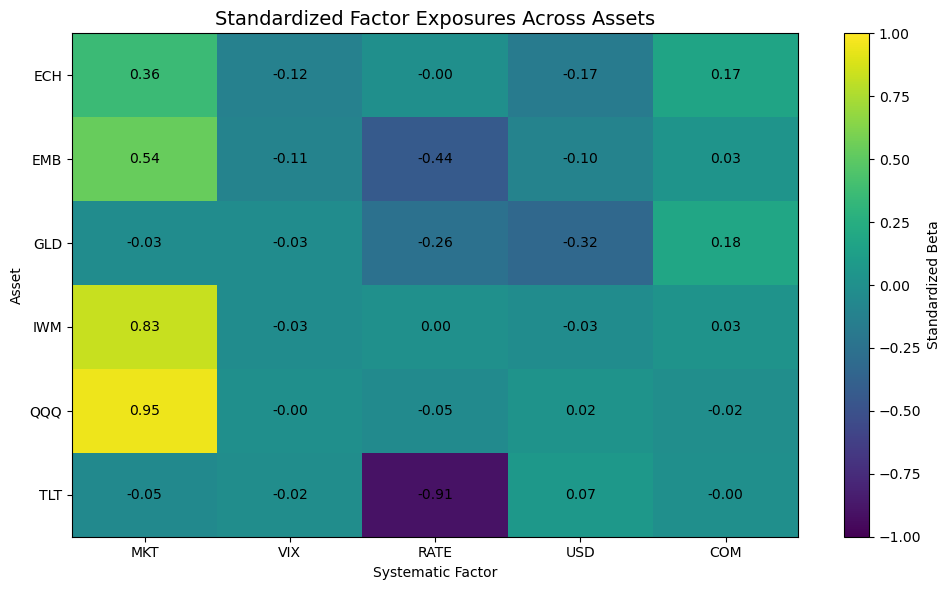

In [27]:
# Heatmap of standardized factor exposures

fig, ax = plt.subplots(figsize=(10, 6))

data = standardized_exposures.astype(float).values

im = ax.imshow(
    data,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(standardized_exposures.columns)))
ax.set_xticklabels(standardized_exposures.columns)

ax.set_yticks(range(len(standardized_exposures.index)))
ax.set_yticklabels(standardized_exposures.index)

# Add values inside cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Standardized Factor Exposures Across Assets",
    fontsize=14
)

ax.set_xlabel("Systematic Factor")
ax.set_ylabel("Asset")

fig.colorbar(
    im,
    ax=ax,
    label="Standardized Beta"
)

plt.tight_layout()

plt.savefig(
    "figures/standardized_factor_exposures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

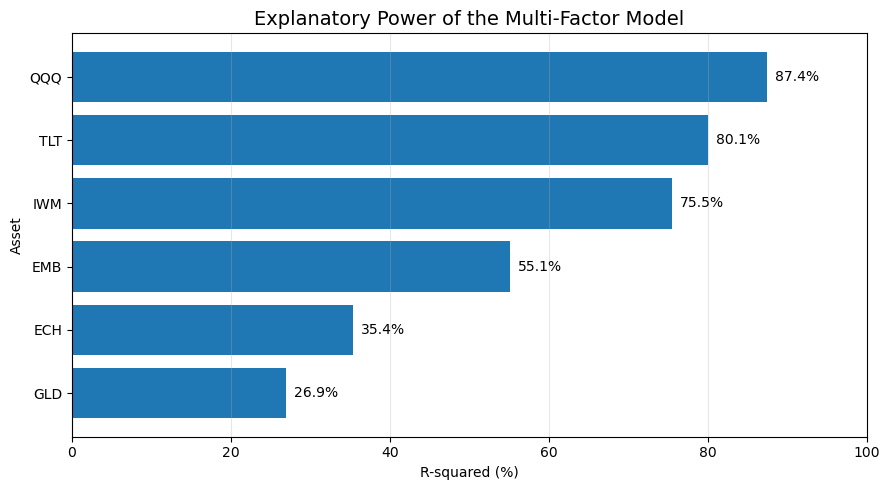

In [28]:
# Plot static model explanatory power

r2_plot = (
    model_fit["R2_pct"]
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    r2_plot.index,
    r2_plot.values
)

ax.set_title(
    "Explanatory Power of the Multi-Factor Model",
    fontsize=14
)

ax.set_xlabel("R-squared (%)")
ax.set_ylabel("Asset")

ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "figures/factor_model_explanatory_power.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

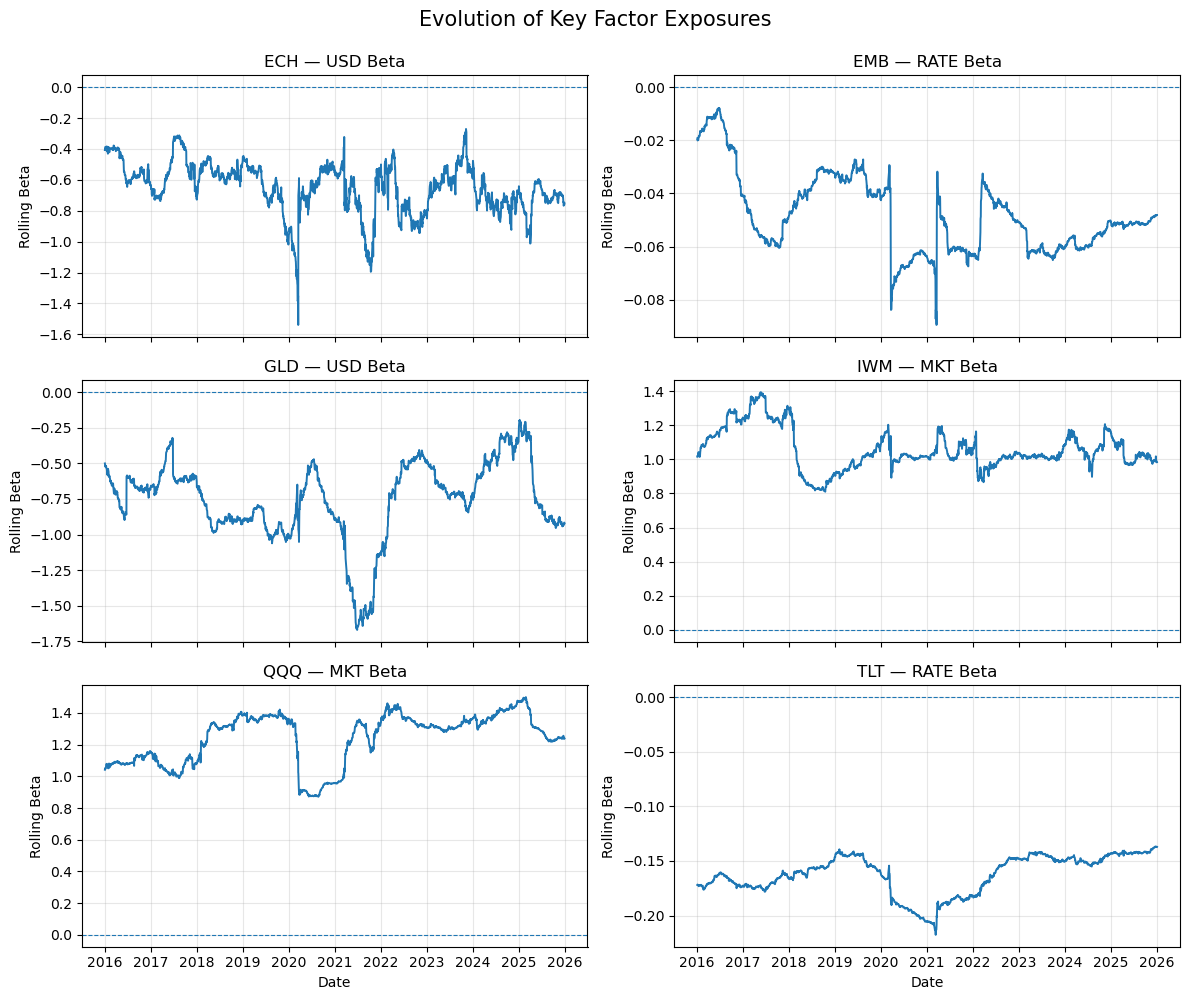

In [29]:
# Plot evolution of key rolling factor exposures

key_exposures = {
    "ECH": ("F_USD", "USD"),
    "EMB": ("F_RATE", "RATE"),
    "GLD": ("F_USD", "USD"),
    "IWM": ("F_MKT", "MKT"),
    "QQQ": ("F_MKT", "MKT"),
    "TLT": ("F_RATE", "RATE")
}

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 10),
    sharex=True
)

axes = axes.flatten()

for ax, (asset, (factor, factor_label)) in zip(
    axes,
    key_exposures.items()
):
    series = rolling_results[asset][factor]

    ax.plot(
        series.index,
        series,
        linewidth=1.4
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(f"{asset} — {factor_label} Beta")
    ax.set_ylabel("Rolling Beta")
    ax.grid(alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Date")

fig.suptitle(
    "Evolution of Key Factor Exposures",
    fontsize=15,
    y=0.995
)

plt.tight_layout()

plt.savefig(
    "figures/key_rolling_factor_exposures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

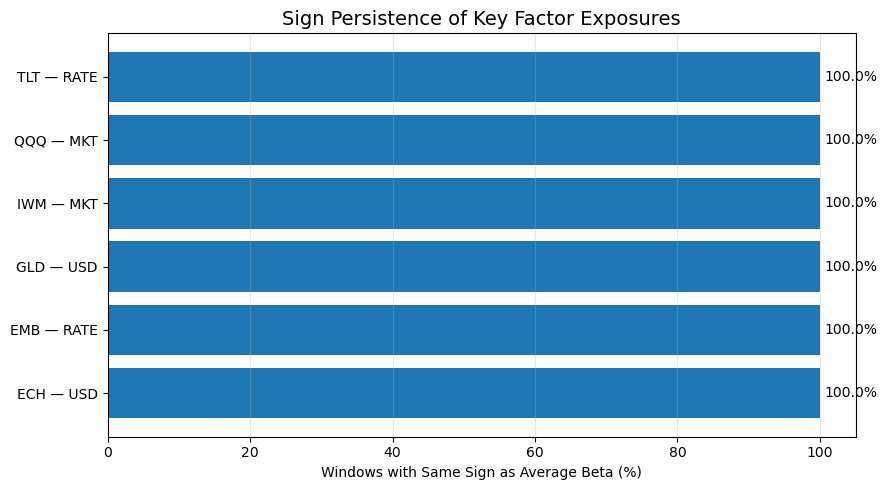

In [30]:
# Sign persistence of key factor exposures

key_persistence = []

for asset, (factor, factor_label) in key_exposures.items():

    beta_series = rolling_results[asset][factor]
    mean_beta = beta_series.mean()

    if mean_beta > 0:
        persistence = (beta_series > 0).mean() * 100
    else:
        persistence = (beta_series < 0).mean() * 100

    key_persistence.append({
        "Exposure": f"{asset} — {factor_label}",
        "Persistence": persistence
    })

key_persistence_df = (
    pd.DataFrame(key_persistence)
    .sort_values("Persistence")
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    key_persistence_df["Exposure"],
    key_persistence_df["Persistence"]
)

ax.set_title(
    "Sign Persistence of Key Factor Exposures",
    fontsize=14
)

ax.set_xlabel("Windows with Same Sign as Average Beta (%)")
ax.set_xlim(0, 105)
ax.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "figures/key_factor_sign_persistence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

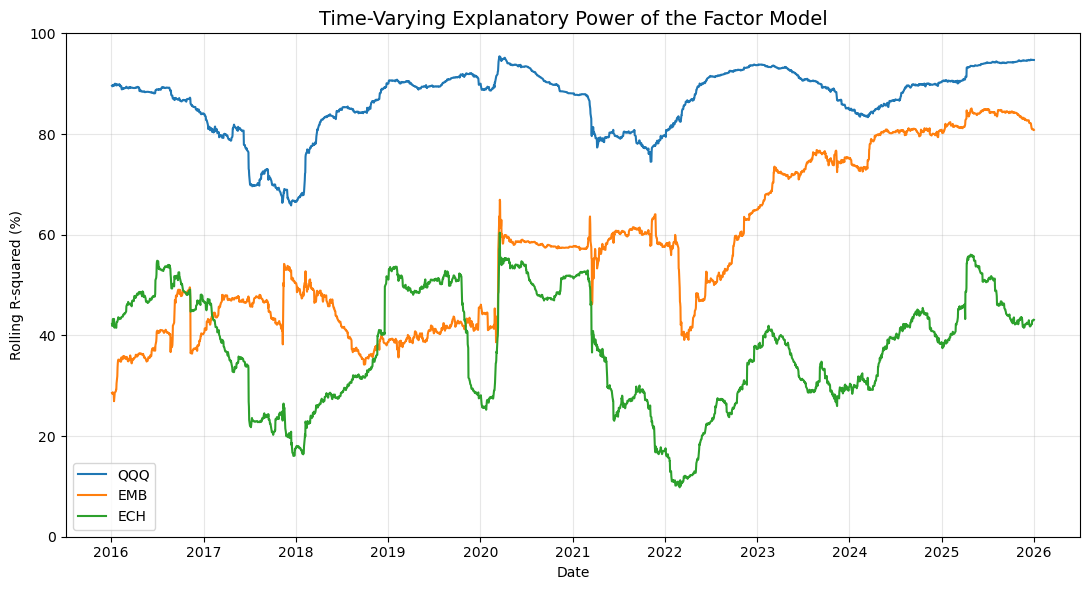

In [31]:
# Rolling explanatory power for representative assets

fig, ax = plt.subplots(figsize=(11, 6))

for asset in ["QQQ", "EMB", "ECH"]:
    ax.plot(
        rolling_results[asset].index,
        rolling_results[asset]["R2"] * 100,
        label=asset,
        linewidth=1.5
    )

ax.set_title(
    "Time-Varying Explanatory Power of the Factor Model",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Rolling R-squared (%)")

ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/rolling_factor_model_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Equal-weight multi-asset portfolio factor model

portfolio_assets = asset_returns.columns.tolist()

equal_weights = np.repeat(
    1 / len(portfolio_assets),
    len(portfolio_assets)
)

portfolio_returns = (
    asset_returns[portfolio_assets]
    @ equal_weights
)

portfolio_returns.name = "Equal_Weight_Portfolio"

portfolio_model_data = (
    portfolio_returns.to_frame()
    .join(factors.add_prefix("F_"), how="inner")
    .dropna()
)

y_portfolio = portfolio_model_data["Equal_Weight_Portfolio"]

X_portfolio = sm.add_constant(
    portfolio_model_data[factor_cols]
)

portfolio_factor_model = sm.OLS(
    y_portfolio,
    X_portfolio
).fit(cov_type="HC3")

print(portfolio_factor_model.summary())

                              OLS Regression Results                              
Dep. Variable:     Equal_Weight_Portfolio   R-squared:                       0.898
Model:                                OLS   Adj. R-squared:                  0.898
Method:                     Least Squares   F-statistic:                     1619.
Date:                    Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                            22:27:47   Log-Likelihood:                 12664.
No. Observations:                    2763   AIC:                        -2.532e+04
Df Residuals:                        2757   BIC:                        -2.528e+04
Df Model:                               5                                         
Covariance Type:                      HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       

In [33]:
# Factor risk attribution for the equal-weight portfolio

beta = (
    portfolio_factor_model.params[factor_cols]
    .values
)

factor_cov = (
    portfolio_model_data[factor_cols]
    .cov()
    .values
)

# Systematic variance
systematic_variance = beta @ factor_cov @ beta

# Euler contribution of each factor
factor_contributions = beta * (factor_cov @ beta)

factor_risk_attribution = pd.DataFrame(
    {
        "Factor": [
            factor.replace("F_", "")
            for factor in factor_cols
        ],
        "Variance_Contribution": factor_contributions,
        "Share_of_Systematic_Risk_pct":
            factor_contributions
            / systematic_variance
            * 100
    }
)

# Residual and total variance
residual_variance = portfolio_factor_model.resid.var()

total_model_variance = (
    systematic_variance + residual_variance
)

print(
    "Systematic variance:",
    round(systematic_variance, 8)
)

print(
    "Residual variance:",
    round(residual_variance, 8)
)

print(
    "Systematic share of total variance (%):",
    round(
        systematic_variance
        / total_model_variance
        * 100,
        2
    )
)

print(
    "\nFactor risk attribution:"
)

display(
    factor_risk_attribution.round({
        "Variance_Contribution": 8,
        "Share_of_Systematic_Risk_pct": 2
    })
)

print(
    "\nSum of factor contributions (%):",
    round(
        factor_risk_attribution[
            "Share_of_Systematic_Risk_pct"
        ].sum(),
        2
    )
)

Systematic variance: 5.396e-05
Residual variance: 6.12e-06
Systematic share of total variance (%): 89.82

Factor risk attribution:


,Factor,Variance_Contribution,Share_of_Systematic_Risk_pct
0,MKT,0.000037,67.96
1,VIX,0.000002,4.37
2,RATE,0.000002,2.80
3,USD,0.000002,3.27
4,COM,0.000012,21.61



Sum of factor contributions (%): 100.0


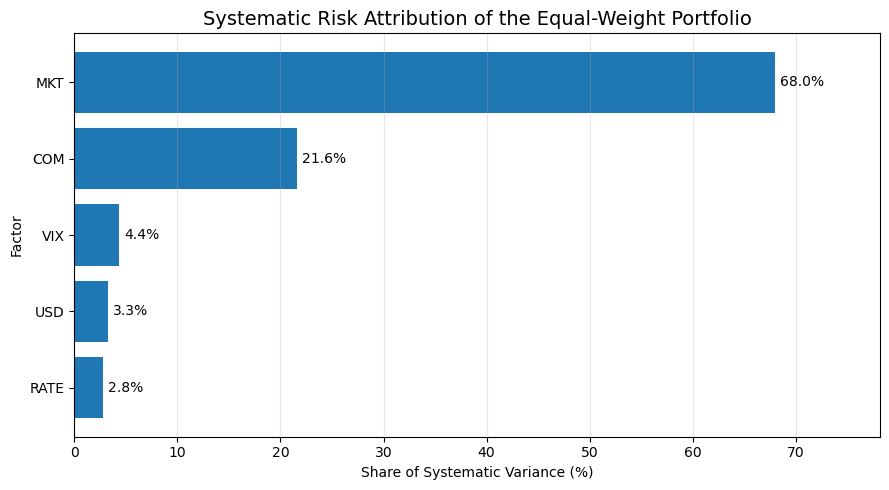

In [34]:
# Plot systematic factor risk attribution

risk_plot = (
    factor_risk_attribution
    .set_index("Factor")["Share_of_Systematic_Risk_pct"]
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    risk_plot.index,
    risk_plot.values
)

ax.set_title(
    "Systematic Risk Attribution of the Equal-Weight Portfolio",
    fontsize=14
)

ax.set_xlabel("Share of Systematic Variance (%)")
ax.set_ylabel("Factor")

ax.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

ax.set_xlim(
    0,
    risk_plot.max() * 1.15
)

plt.tight_layout()

plt.savefig(
    "figures/portfolio_factor_risk_attribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Rolling factor exposures of the equal-weight portfolio

portfolio_rolling_data = (
    portfolio_returns.to_frame()
    .join(factors.add_prefix("F_"), how="inner")
    .dropna()
)

portfolio_rolling_betas = rolling_factor_betas(
    data=portfolio_rolling_data,
    asset="Equal_Weight_Portfolio",
    factors=factor_cols,
    window=252
)

print("Portfolio rolling factor model:")
print("Dimensions:", portfolio_rolling_betas.shape)
print(
    "Period:",
    portfolio_rolling_betas.index.min().date(),
    "to",
    portfolio_rolling_betas.index.max().date()
)

print("\nRolling beta summary:")

display(
    portfolio_rolling_betas[
        factor_cols + ["R2"]
    ].describe().T.round(4)
)

Portfolio rolling factor model:
Dimensions: (2512, 7)
Period: 2016-01-04 to 2025-12-31

Rolling beta summary:


,count,mean,std,min,25%,50%,75%,max
F_MKT,2512.0,0.5030,0.0425,0.3902,0.4822,0.4981,0.5202,0.6333
F_VIX,2512.0,-0.0002,0.0002,-0.0007,-0.0003,-0.0002,-0.0001,0.0003
F_RATE,2512.0,-0.0334,0.0058,-0.0550,-0.0364,-0.0325,-0.0296,-0.0212
F_USD,2512.0,-0.1808,0.0545,-0.3796,-0.1999,-0.1759,-0.1496,-0.0727
F_COM,2512.0,0.1686,0.0219,0.1273,0.1495,0.1702,0.1834,0.2216
R2,2512.0,0.8888,0.0411,0.7731,0.8615,0.8949,0.9231,0.9549


In [36]:
# Rolling systematic factor risk attribution

rolling_risk_results = []

window = 252

for end in range(window, len(portfolio_rolling_data) + 1):

    sample = portfolio_rolling_data.iloc[end - window:end]

    date = sample.index[-1]

    y = sample["Equal_Weight_Portfolio"]
    X = sm.add_constant(sample[factor_cols])

    model = sm.OLS(y, X).fit()

    beta = model.params[factor_cols].values

    factor_cov = sample[factor_cols].cov().values

    systematic_variance = beta @ factor_cov @ beta

    contributions = beta * (factor_cov @ beta)

    shares = contributions / systematic_variance * 100

    row = {
        "Date": date,
        "Systematic_Variance": systematic_variance,
        "R2": model.rsquared
    }

    for factor, share in zip(factor_cols, shares):
        row[factor.replace("F_", "")] = share

    rolling_risk_results.append(row)

rolling_factor_risk = (
    pd.DataFrame(rolling_risk_results)
    .set_index("Date")
)

print("Rolling factor risk attribution:")
print("Dimensions:", rolling_factor_risk.shape)

print("\nAverage share of systematic risk (%):")

display(
    rolling_factor_risk[
        ["MKT", "VIX", "RATE", "USD", "COM"]
    ]
    .describe()
    .T
    .round(2)
)

print(
    "\nMaximum deviation from 100%:",
    round(
        (
            rolling_factor_risk[
                ["MKT", "VIX", "RATE", "USD", "COM"]
            ].sum(axis=1) - 100
        ).abs().max(),
        8
    )
)


Rolling factor risk attribution:
Dimensions: (2512, 7)

Average share of systematic risk (%):


,count,mean,std,min,25%,50%,75%,max
MKT,2512.0,65.43,8.86,44.34,59.59,65.18,70.46,98.41
VIX,2512.0,4.06,3.81,-8.90,1.17,3.29,6.55,15.50
RATE,2512.0,3.09,7.61,-9.20,-3.76,1.80,8.20,24.17
USD,2512.0,4.01,2.55,-1.57,2.08,4.09,5.54,11.29
COM,2512.0,23.42,4.96,11.63,19.15,23.19,26.72,41.26



Maximum deviation from 100%: 0.0


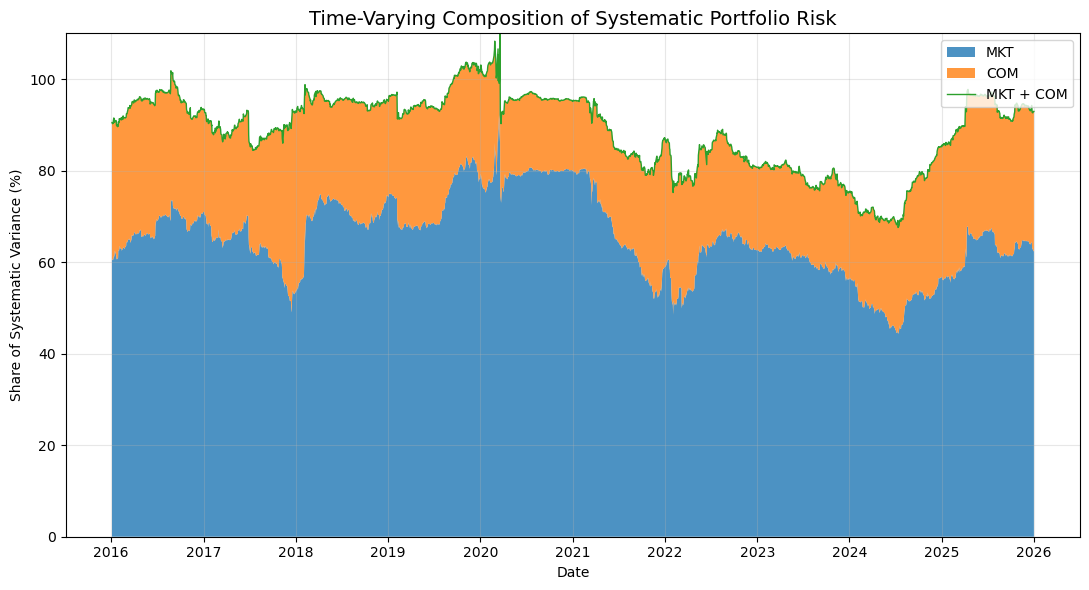

In [37]:
# Dynamic contribution of dominant systematic risk factors

fig, ax = plt.subplots(figsize=(11, 6))

ax.stackplot(
    rolling_factor_risk.index,
    rolling_factor_risk["MKT"],
    rolling_factor_risk["COM"],
    labels=["MKT", "COM"],
    alpha=0.8
)

ax.plot(
    rolling_factor_risk.index,
    rolling_factor_risk[
        ["MKT", "COM"]
    ].sum(axis=1),
    linewidth=1,
    label="MKT + COM"
)

ax.set_title(
    "Time-Varying Composition of Systematic Portfolio Risk",
    fontsize=14
)

ax.set_xlabel("Date")
ax.set_ylabel("Share of Systematic Variance (%)")

ax.set_ylim(0, 110)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/rolling_portfolio_factor_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Average systematic risk attribution during stress periods

stress_risk_attribution = []

risk_factors = ["MKT", "VIX", "RATE", "USD", "COM"]

for period_name, (start, end) in stress_periods.items():

    period_risk = rolling_factor_risk.loc[
        start:end,
        risk_factors
    ]

    average_contribution = period_risk.mean()

    row = {
        "Period": period_name
    }

    for factor in risk_factors:
        row[factor] = average_contribution[factor]

    stress_risk_attribution.append(row)

stress_risk_attribution = (
    pd.DataFrame(stress_risk_attribution)
    .set_index("Period")
)

print(
    "Average systematic risk attribution "
    "during stress periods (%):"
)

display(
    stress_risk_attribution.round(2)
)

print("\nRow sums:")

display(
    stress_risk_attribution
    .sum(axis=1)
    .round(2)
)

Average systematic risk attribution during stress periods (%):


,MKT,VIX,RATE,USD,COM
Period,,,,,
COVID-19 Shock,80.50,6.99,-5.74,0.23,18.02
2022 Tightening Shock,60.32,8.90,3.68,4.45,22.65
2025 Market Uncertainty Shock,61.41,-0.08,4.52,3.30,30.86



Row sums:


Period
COVID-19 Shock                   100.0
2022 Tightening Shock            100.0
2025 Market Uncertainty Shock    100.0
dtype: float64

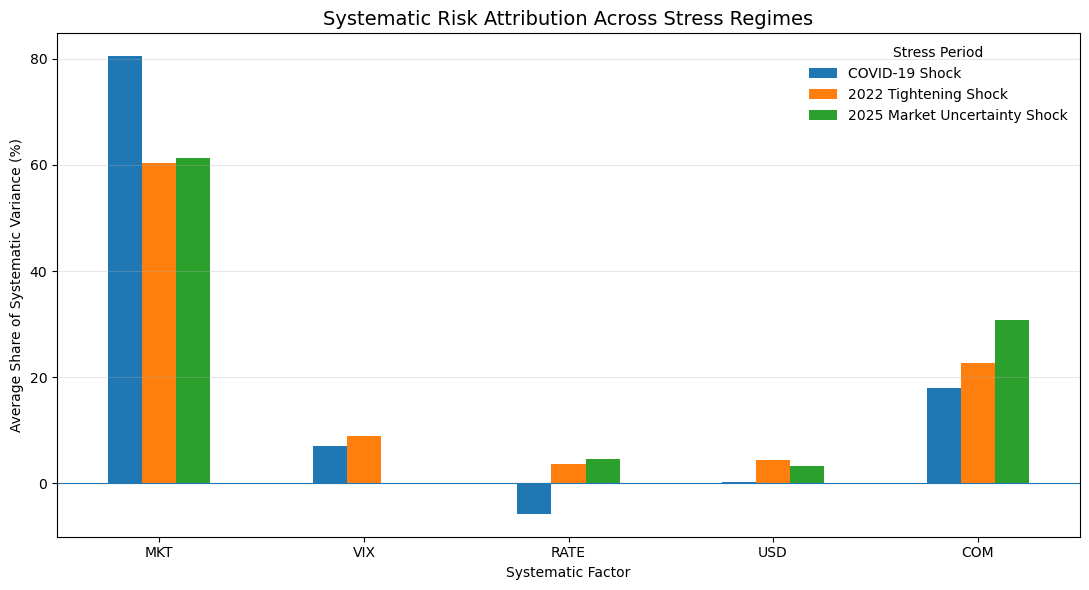

In [39]:
# Compare systematic risk attribution across stress periods

stress_plot = stress_risk_attribution.T

fig, ax = plt.subplots(figsize=(11, 6))

stress_plot.plot(
    kind="bar",
    ax=ax
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_title(
    "Systematic Risk Attribution Across Stress Regimes",
    fontsize=14
)

ax.set_xlabel("Systematic Factor")
ax.set_ylabel("Average Share of Systematic Variance (%)")

ax.legend(
    title="Stress Period",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/stress_factor_risk_attribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# Export final factor dataset used in the analysis

factors.to_csv(
    "data/factors_clean.csv",
    index=True
)

factor_check = pd.read_csv(
    "data/factors_clean.csv",
    index_col=0,
    parse_dates=True
)

print("Factor dataset exported successfully.")
print("Dimensions:", factor_check.shape)
print(
    "Period:",
    factor_check.index.min().date(),
    "to",
    factor_check.index.max().date()
)
print("Missing values:", factor_check.isna().sum().sum())
print("Columns:", factor_check.columns.tolist())

Factor dataset exported successfully.
Dimensions: (2763, 5)
Period: 2015-01-05 to 2025-12-31
Missing values: 0
Columns: ['MKT', 'VIX', 'RATE', 'USD', 'COM']


In [41]:
# Final summary of key project findings

final_summary = pd.DataFrame({
    "Metric": [
        "Static portfolio R-squared",
        "Average rolling portfolio R-squared",
        "Minimum rolling portfolio R-squared",
        "Maximum rolling portfolio R-squared",
        "MKT share of systematic risk",
        "COM share of systematic risk",
        "MKT average rolling risk share",
        "COM average rolling risk share",
        "COVID MKT risk share",
        "2022 MKT risk share",
        "2025 MKT risk share",
        "COVID COM risk share",
        "2022 COM risk share",
        "2025 COM risk share"
    ],
    "Value": [
        portfolio_factor_model.rsquared * 100,
        portfolio_rolling_betas["R2"].mean() * 100,
        portfolio_rolling_betas["R2"].min() * 100,
        portfolio_rolling_betas["R2"].max() * 100,
        factor_risk_attribution
            .set_index("Factor")
            .loc["MKT", "Share_of_Systematic_Risk_pct"],
        factor_risk_attribution
            .set_index("Factor")
            .loc["COM", "Share_of_Systematic_Risk_pct"],
        rolling_factor_risk["MKT"].mean(),
        rolling_factor_risk["COM"].mean(),
        stress_risk_attribution.loc[
            "COVID-19 Shock", "MKT"
        ],
        stress_risk_attribution.loc[
            "2022 Tightening Shock", "MKT"
        ],
        stress_risk_attribution.loc[
            "2025 Market Uncertainty Shock", "MKT"
        ],
        stress_risk_attribution.loc[
            "COVID-19 Shock", "COM"
        ],
        stress_risk_attribution.loc[
            "2022 Tightening Shock", "COM"
        ],
        stress_risk_attribution.loc[
            "2025 Market Uncertainty Shock", "COM"
        ]
    ]
})

final_summary["Value"] = final_summary["Value"].round(2)

display(final_summary)

,Metric,Value
0,Static portfolio R-squared,89.82
1,Average rolling portfolio R-squared,88.88
2,Minimum rolling portfolio R-squared,77.31
3,Maximum rolling portfolio R-squared,95.49
4,MKT share of systematic risk,67.96
5,COM share of systematic risk,21.61
6,MKT average rolling risk share,65.43
7,COM average rolling risk share,23.42
8,COVID MKT risk share,80.50
9,2022 MKT risk share,60.32


## Conclusions

This project examined the systematic drivers of returns and risk across a diversified multi-asset universe using market, volatility, interest-rate, U.S. dollar, and commodity factors.

### 1. Factor exposures differ substantially across asset classes

The static multi-factor regressions reveal economically distinct exposure profiles. U.S. equities are primarily driven by the market factor, while long-duration Treasury bonds exhibit a dominant negative sensitivity to interest-rate changes. Emerging-market bonds combine equity-market and interest-rate exposure, whereas Chilean equities and gold display more diversified factor structures involving market, currency, commodity, and uncertainty conditions.

After standardizing the coefficients, these differences become particularly clear. QQQ and IWM are strongly dominated by market exposure, TLT by interest-rate exposure, while ECH and GLD depend on a broader combination of systematic drivers.

### 2. The explanatory power of systematic factors varies across assets

The five-factor model explains approximately 87% of QQQ return variation, 80% for TLT, and 76% for IWM. Explanatory power is lower for EMB, ECH, and GLD, indicating a larger role for idiosyncratic or omitted drivers in these assets.

Therefore, the relevance of systematic factor models is not uniform across asset classes.

### 3. Factor exposures are dynamic rather than constant

Rolling 252-day regressions show that factor sensitivities change materially through time.

However, several economically important exposures are highly persistent in direction. ECH remains negatively exposed to the U.S. dollar, EMB and TLT maintain negative interest-rate exposure, GLD remains negatively exposed to the dollar, and IWM and QQQ retain positive market exposure throughout the rolling sample.

The main source of instability is therefore often the magnitude of exposure rather than its direction.

### 4. Diversification stabilizes factor exposures but does not eliminate regime dependence

For the equal-weight multi-asset portfolio, the factor model explains 89.82% of return variation in the full-sample regression.

Its rolling explanatory power averages 88.88%, but ranges from 77.31% to 95.49%, demonstrating that even a diversified portfolio experiences meaningful changes in systematic exposure across market environments.

Portfolio-level factor betas are generally more stable than those of individual assets, suggesting that asset diversification partially stabilizes systematic sensitivities.

### 5. Asset diversification does not necessarily imply factor diversification

The systematic risk attribution shows that the market factor accounts for approximately 67.96% of systematic portfolio variance, while the commodity factor contributes another 21.61%.

Together, these two factors account for almost 90% of systematic risk despite the portfolio containing eight assets across multiple asset classes.

This demonstrates an important portfolio-management principle: diversification across securities does not automatically produce diversification across underlying sources of risk.

### 6. The composition of systematic risk changes across regimes

Rolling factor risk attribution confirms that the source of portfolio risk is not constant through time.

On average, the market factor contributes 65.43% of systematic risk and the commodity factor 23.42%, but their relative importance changes considerably across rolling windows.

The stress-period analysis reinforces this result. Market risk represented approximately 80.50% of systematic risk during the COVID-19 shock, compared with 60.32% during the 2022 tightening episode and 61.41% during the 2025 market-uncertainty period. Commodity risk increased from 18.02% during COVID-19 to 30.86% in the 2025 window.

Interest-rate, volatility, and currency contributions also change across regimes and may occasionally become negative because factor covariances can partially offset systematic portfolio variance.

### Final Insight

The analysis shows that portfolio risk should not be understood solely through total volatility or static asset correlations.

A diversified portfolio can still contain concentrated systematic exposures, and those exposures can change materially as financial conditions evolve.

For risk management and asset allocation, factor analysis therefore provides an additional layer of information: it identifies not only how much risk a portfolio carries, but also where that risk comes from and how its underlying drivers evolve through time.